In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("traffic.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

First 5 rows:


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

Summary Statistics:


,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


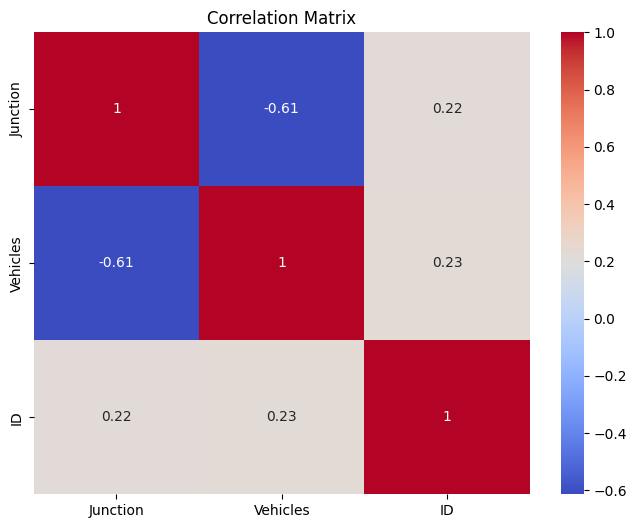

In [12]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

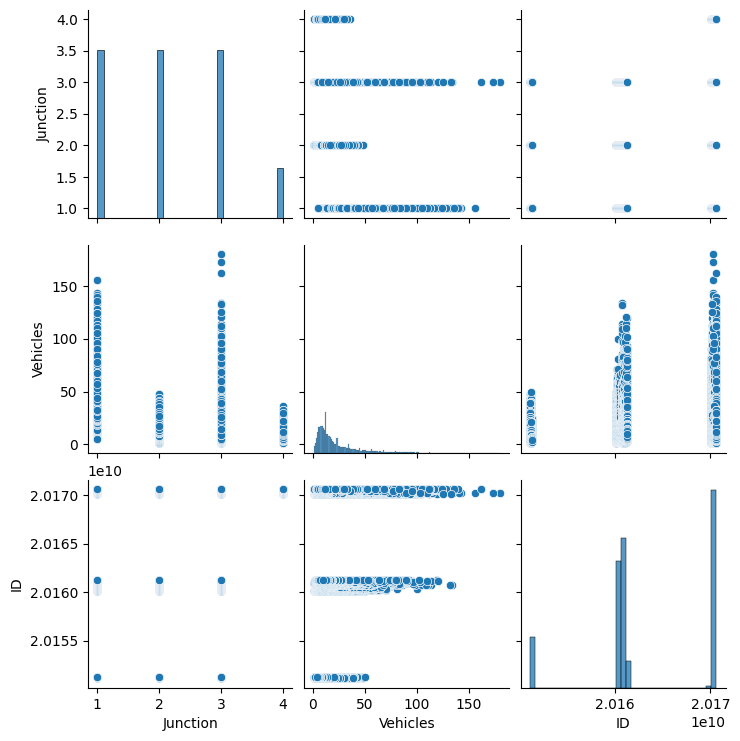

In [13]:
sns.pairplot(df)
plt.show()

In [14]:
X = df.select_dtypes(include=[np.number])

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

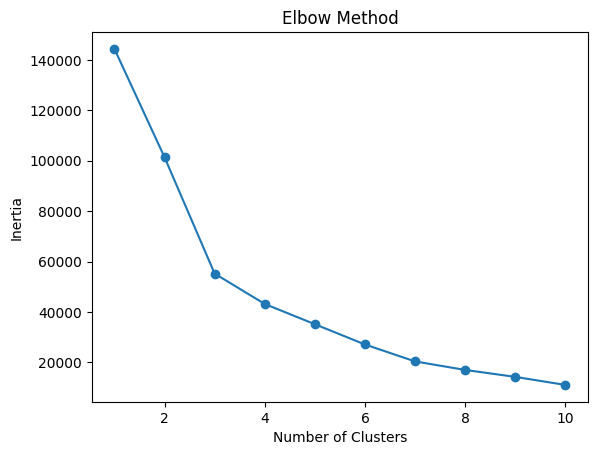

In [16]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [17]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

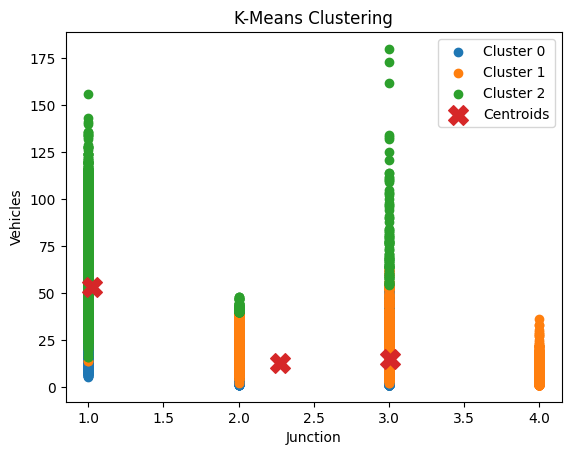

In [18]:
x_col = X.columns[0]
y_col = X.columns[1]

plt.figure()

for i in range(k):
    plt.scatter(df[df['Cluster']==i][x_col],
                df[df['Cluster']==i][y_col],
                label=f"Cluster {i}")

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1],
            marker='X', s=200, label='Centroids')

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [19]:
display(df.head())

,DateTime,Junction,Vehicles,ID,Cluster
0,2015-11-01 00:00:00,1,15,20151101001,0
1,2015-11-01 01:00:00,1,13,20151101011,0
2,2015-11-01 02:00:00,1,10,20151101021,0
3,2015-11-01 03:00:00,1,7,20151101031,0
4,2015-11-01 04:00:00,1,9,20151101041,0
